In [1]:
import os

from dotenv import load_dotenv
load_dotenv()

api_key = os.getenv("OLLAMA_API_KEY")


In [ ]:
from langchain_openai import ChatOpenAI

qwen3_coder = ChatOpenAI(
    model="qwen3-coder:480b-cloud",
    base_url="https://ollama.com/v1",
    api_key=api_key,
    temperature=0.2
)

qwen3_coder

ChatOpenAI(output_version=None, client=<openai.resources.chat.completions.completions.Completions object at 0x1164ba5d0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x1164b9090>, root_client=<openai.OpenAI object at 0x1164ba490>, root_async_client=<openai.AsyncOpenAI object at 0x1164b9810>, model_name='qwen3-coder:480b-cloud', temperature=0.2, model_kwargs={'response_format': {'type': 'json_object'}}, openai_api_key=SecretStr('**********'), openai_api_base='https://ollama.com/v1', openai_proxy=None, stream_chunk_timeout=120.0)

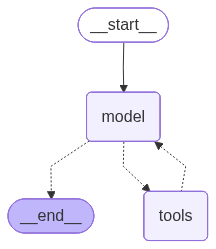

In [25]:
from langchain.agents import create_agent

def get_weather(city:str) -> str:
    """Get the weather of a city."""
    return f"weather of the {city} is sunny."

agent = create_agent(
    model=qwen3_coder,
    tools = [get_weather],
    system_prompt="You are a helpful assistant."
)

agent

In [26]:
response = agent.invoke(
    {"messages": [{
        "role": "user",
        "content": "What is the weather like in New York ?"
    }]}
)

response["messages"][-1].content

ValueError: `get_weather` is not strict. Only `strict` function tools can be auto-parsed

In [16]:
for chunk in qwen3_coder.stream("Write me a 200 word paragraph on artificial intelligence."):
    print(chunk.text, end="|", flush=True)



Art|ificial intelligence represents| one| of the most transformative| technological advances| of| the| 21st| century|, fundamentally| resh|aping how we| live|, work, and| interact with| technology|. At| its| core, AI involves| creating| computer| systems capable| of performing| tasks that traditionally| require human intelligence,| including| learning|, reasoning, problem|-solving, and decision|-making. Machine| learning,| a| subset| of AI, enables| systems| to improve| their performance through| experience|,| while| deep| learning| mim|ics| neural| networks| to process| complex data| patterns. Today|'s| AI applications span| countless| industries:| healthcare| systems| use| AI for disease| diagnosis and| drug| discovery|, financial| institutions| employ| it| for fraud detection and| algorithm|ic| trading, and transportation| companies leverage| AI for autonomous| vehicles| and| route| optimization. Virtual| assistants like| Siri and| Alexa have become| household| staples|, while recom

In [17]:
from langchain.messages import AIMessage, SystemMessage, HumanMessage

system_msg = SystemMessage("""
    You are a helpful coding assistant with expertise in python development and web frameworks.
    Always provide code examples and explain your reasoning.
    Be concise but thorough in your explanations.
""")

messages = [
    system_msg,
    HumanMessage("How do I create a REST api ?")
]

response = qwen3_coder.invoke(messages)
print(response.content)

KeyboardInterrupt: 

In [5]:
response.usage_metadata

{'input_tokens': 56,
 'output_tokens': 1231,
 'total_tokens': 1287,
 'input_token_details': {},
 'output_token_details': {}}

In [30]:
from pydantic import BaseModel, Field, ConfigDict

class Movie(BaseModel):
    title : str = Field(description="The title of the movie")
    year : int = Field(description="Year in which the movie was released")
    director : str = Field(description="The director of the movie")
    rating : float = Field(description="The movie's user rating out of 10")



In [33]:
from dataclasses import dataclass

@dataclass
class ContactInfo:
    """Contact information of a person"""

    name: str
    email: str
    phone: str

agent = create_agent(
    model=qwen3_coder,
    response_format=ContactInfo
)



response = agent.invoke(
    {"messages": [{
        "role": "user",
        "content": "Extract information from John Doe, johnoepundachi@gmail.com, +718 12345 54321"
    }]}
)


response["structured_output"]

ValueError: `ContactInfo` is not strict. Only `strict` function tools can be auto-parsed